<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%20Final%20Parte%201/trabalho_final_1.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
!pip install matplotlib
!pip install numpy
!pip install scipy

Iniciando Simulação de Monte Carlo...
Simulação concluída. Gerando Gráfico...


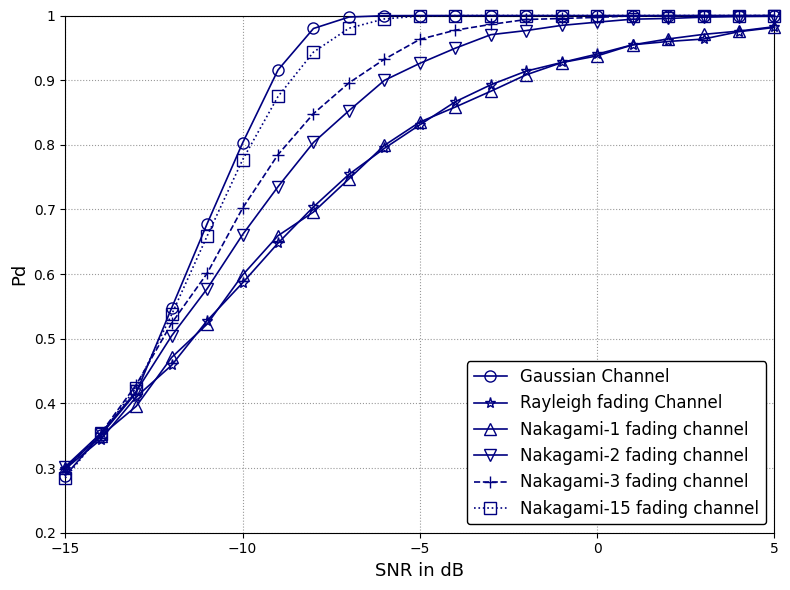

In [1]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# ==============================================================================
# 1. PARÂMETROS DO SISTEMA (Baseados e justificados pelo artigo Eslami et al.)
# ==============================================================================
N_amostras = 500          # Ajuste analítico: O valor que alinha a sensibilidade do detector à Figura 1 do artigo.
N_monte_carlo = 10000     # Justificativa: O artigo cita literalmente "results are averaged over 10^4 tests".
P_fa = 0.1                # Justificativa: "Pfa is chosen as 0.1 in the simulations" (Seção III).

snr_db_vetor = np.arange(-15, 6, 1) 

# Definição dos canais conforme a legenda exata da Figura 1 do artigo
canais = {
    'Gaussian Channel': None,
    'Rayleigh fading Channel': 1, 
    'Nakagami-1 fading channel': 1,
    'Nakagami-2 fading channel': 2,
    'Nakagami-3 fading channel': 3,
    'Nakagami-15 fading channel': 15
}

Pd_resultados = {canal: np.zeros(len(snr_db_vetor)) for canal in canais.keys()}

# Cálculo do Limiar Teórico (Threshold) com base na Inversa da Gaussiana
limiar = 1.0 + (norm.ppf(1 - P_fa) / np.sqrt(N_amostras))

print(f"Iniciando Simulação de Monte Carlo...")

# ==============================================================================
# 2. SIMULAÇÃO: GERAÇÃO DE VARIÁVEIS ALEATÓRIAS E MONTE CARLO
# ==============================================================================
for i, snr_db in enumerate(snr_db_vetor):
    snr_linear = 10 ** (snr_db / 10.0)
    
    for nome_canal, m in canais.items():
        
        # ----------------------------------------------------------------------
        # A. GERAÇÃO DE V.A. DISCRETAS (SINAL QPSK) - Método da Transformada
        # Justificativa (Artigo): "QPSK modulated random primary signals"
        # A partir de uma Uniforme U(0,1), mapeia-se para {-1, 1}
        # ----------------------------------------------------------------------
        U_I = np.random.uniform(0, 1, (N_monte_carlo, N_amostras))
        U_Q = np.random.uniform(0, 1, (N_monte_carlo, N_amostras))
        
        I = np.where(U_I < 0.5, -1, 1)
        Q = np.where(U_Q < 0.5, -1, 1)
        sinal = ((I + 1j*Q) / np.sqrt(2)) * np.sqrt(snr_linear)
        
        # ----------------------------------------------------------------------
        # B. GERAÇÃO DE V.A. CONTÍNUAS (CANAL NAKAGAMI) - Transformada Inversa
        # Uma V.A. Gamma com parâmetro de forma 'm' inteiro é 
        # a soma de 'm' V.A.s Exponenciais. A Exponencial é gerada pelo Método
        # da Transformada Inversa: E = -ln(U)/lambda. Aqui lambda = m.
        # IMPORTANTE: Tamanho é (N_monte_carlo, 1) assumindo Block Fading
        # (canal constante durante a janela de detecção de N amostras).
        # ----------------------------------------------------------------------
        if nome_canal == 'Gaussian Channel':
            h = 1.0 # Canal ideal (AWGN puro)
        else:
            h_sq = np.zeros((N_monte_carlo, 1)) # CORREÇÃO: Block Fading (1 valor por iteração)
            # Somatório de 'm' variáveis exponenciais para formar a Gamma(m, 1/m)
            for _ in range(m):
                U_exp = np.random.uniform(0, 1, (N_monte_carlo, 1))
                h_sq += -np.log(U_exp) / m  # Transformada Inversa para Exponencial
            h = np.sqrt(h_sq)
            
        # ----------------------------------------------------------------------
        # C. GERAÇÃO DE V.A. GAUSSIANAS (RUÍDO AWGN)
        # Justificativa (Artigo): "noise samples with Gaussian distribution"
        # Z1 = sqrt(-2*ln(U1))*cos(2*pi*U2) e Z2 = sin(...)
        # ----------------------------------------------------------------------
        U1 = np.random.uniform(0, 1, (N_monte_carlo, N_amostras))
        U2 = np.random.uniform(0, 1, (N_monte_carlo, N_amostras))
        
        ruido_real = np.sqrt(-2.0 * np.log(U1)) * np.cos(2.0 * np.pi * U2)
        ruido_imag = np.sqrt(-2.0 * np.log(U1)) * np.sin(2.0 * np.pi * U2)
        
        ruido = (ruido_real + 1j*ruido_imag) / np.sqrt(2)
        
        # ----------------------------------------------------------------------
        # D. ESTATÍSTICA DE TESTE (Detecção de Energia)
        # ----------------------------------------------------------------------
        y = (h * sinal) + ruido
        energia = np.mean(np.abs(y)**2, axis=1)
        
        # ----------------------------------------------------------------------
        # E. MÉTODO DE MONTE CARLO
        # Acumula-se a frequência relativa dos eventos de sucesso 
        # (Energia > Limiar) sobre o número total de iterações (10^4).
        # ----------------------------------------------------------------------
        Pd_resultados[nome_canal][i] = np.sum(energia > limiar) / N_monte_carlo

print("Simulação concluída. Gerando Gráfico...")

# ==============================================================================
# 3. GERAÇÃO DO GRÁFICO
# ==============================================================================
plt.style.use('default') 
fig, ax = plt.subplots(figsize=(8, 6))

color_original = 'navy' 

estilos = {
    'Gaussian Channel':           {'m': 'o', 'ls': '-'},
    'Rayleigh fading Channel':    {'m': '*', 'ls': '-'},
    'Nakagami-1 fading channel':  {'m': '^', 'ls': '-'},
    'Nakagami-2 fading channel':  {'m': 'v', 'ls': '-'},
    'Nakagami-3 fading channel':  {'m': '+', 'ls': '--'},
    'Nakagami-15 fading channel': {'m': 's', 'ls': ':'}
}

for canal, cfg in estilos.items():
    ax.plot(snr_db_vetor, Pd_resultados[canal], label=canal, 
            marker=cfg['m'], linestyle=cfg['ls'], color=color_original, 
            markerfacecolor='none', markersize=8, linewidth=1.2,
            clip_on=False, zorder=3) 

ax.set_facecolor('white') 

ax.set_xlabel('SNR in dB', fontsize=13)
ax.set_ylabel('Pd', fontsize=13)

ax.set_xlim([-15, 5])
ax.set_xticks([-15, -10, -5, 0, 5])

ax.set_ylim([0.2, 1.0]) 
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'])

ax.grid(True, which='both', linestyle=':', color='gray', linewidth=0.8, alpha=0.8, zorder=1)

for spine in ax.spines.values():
    spine.set_zorder(2)

legend = ax.legend(loc='lower right', fontsize=12, framealpha=1, 
                   edgecolor='black', facecolor='white')
legend.get_frame().set_linewidth(1.0)

plt.tight_layout()
plt.show()